<h1><center>Generative Modeling for Synthetic Healthcare Data and Disease Progression Prediction</center></h1>

<p align="center">
Alzheimer’s Disease Case Study Using Real and Synthetic Clinical Data
</p>

## Project Introduction

The goal of this project is to investigate the application of generative modeling in healthcare, with a particular focus on disease progression prediction. Using Alzheimer’s disease as a case study, the project explores whether synthetic clinical data generated by a Variational Autoencoder (VAE) can be effectively used to train machine learning models.

To achieve this, baseline classification models are first trained on real clinical data and then trained again on synthetic data generated from the learned distribution of the original dataset. The results are compared in order to evaluate the usefulness of synthetic healthcare data for predictive modeling and to assess whether generative models can help address data scarcity and privacy limitations in healthcare.

### Objectives

- **Descriptive:** Analyze and visualize the dataset to better understand the distribution of clinical features and the target variable.
- **Predictive:** Train baseline machine learning models on real clinical data to predict Alzheimer’s disease stage.
- **Generative:** Implement a Variational Autoencoder (VAE) to learn the structure of the real dataset and generate synthetic patient records.
- **Comparative:** Train the same baseline models on synthetic data and compare their performance with models trained on real data.
- **Analytical:** Evaluate whether synthetic healthcare data can serve as a useful alternative for medical prediction tasks.

## Research Question

Can synthetic healthcare data generated by a Variational Autoencoder (VAE) be effectively used to train machine learning models for disease progression prediction?

More specifically, how does the performance of Logistic Regression, Random Forest, and Neural Network models trained on synthetic data compare with the performance of the same models trained on real clinical data in the case of Alzheimer’s disease?

## Assumptions (Hypotheses)

1. Clinical and demographic features such as age, cognitive assessment scores, and family history may show meaningful relationships with Alzheimer’s disease diagnosis and progression.
2. Baseline models trained on real clinical data are expected to achieve stronger predictive performance than models trained only on synthetic data.
3. Synthetic data generated by the VAE may preserve important patterns of the original dataset well enough to support useful predictive modeling, even if some loss in performance is expected.

### Experimental Workflow

- **Exploratory Data Analysis (EDA):** Examine the structure of the dataset, feature distributions, and relationships between variables.
- **Data Preprocessing:** Clean the dataset, encode categorical variables, split the data, and normalize the features.
- **Baseline Modeling on Real Data:** Train Logistic Regression, Random Forest, and Neural Network models on real clinical data.
- **Generative Modeling:** Train a Variational Autoencoder (VAE) on the real training data.
- **Synthetic Data Generation:** Use the trained VAE to generate synthetic patient records.
- **Modeling on Synthetic Data:** Train the same baseline models on synthetic data.
- **Performance Comparison:** Compare results obtained from real-data and synthetic-data training using classification metrics and confusion matrices.

## Reading and Understanding the Data

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn tabulate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import libraries for initial state of data exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
# Read .csv as a dataframe
data = pd.read_csv("alzheimers_disease_data.csv")

data.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [4]:
data.shape

(2149, 35)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

In [6]:
# Check for duplicate rows and missing values
print("Duplicate rows: ", sum(data.duplicated()))
print(data.isnull().sum())

Duplicate rows:  0
PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompleting

In [7]:
data.nunique() # Number of unique values can help in determining which features are numerical which ones are categorical features.

PatientID                    2149
Age                            31
Gender                          2
Ethnicity                       4
EducationLevel                  4
BMI                          2149
Smoking                         2
AlcoholConsumption           2149
PhysicalActivity             2149
DietQuality                  2149
SleepQuality                 2149
FamilyHistoryAlzheimers         2
CardiovascularDisease           2
Diabetes                        2
Depression                      2
HeadInjury                      2
Hypertension                    2
SystolicBP                     90
DiastolicBP                    60
CholesterolTotal             2149
CholesterolLDL               2149
CholesterolHDL               2149
CholesterolTriglycerides     2149
MMSE                         2149
FunctionalAssessment         2149
MemoryComplaints                2
BehavioralProblems              2
ADL                          2149
Confusion                       2
Disorientation

### Initial Data Exploration Summary
- The dataset contains a total of **2,149 observations**
- All values are **non-null** & **numerical**
- There are **no duplicate** records or **missing values**
- After removing **"DoctorInCharge"** and **"PatientID"** features, there are **33 total features** (original 35)

<h1><center>Exploratory Data Analysis (EDA)</center></h1>

### Plot Distribution of Numerical & Categorical Features

In [8]:
# Identify numerical features: features with more than 5 unique values are considered numerical
numerical_columns = [col for col in data.columns if data[col].nunique() > 5]

# Identify categorical features: features that are not numerical and not 'Diagnosis'
categorical_columns = data.columns.difference(numerical_columns).difference(["Diagnosis"]).to_list()

print("Numerical cols:", len(numerical_columns))
print("Categorical cols:", len(categorical_columns))

Numerical cols: 16
Categorical cols: 18


### Distribution of Categorical Features (Count-Plots)

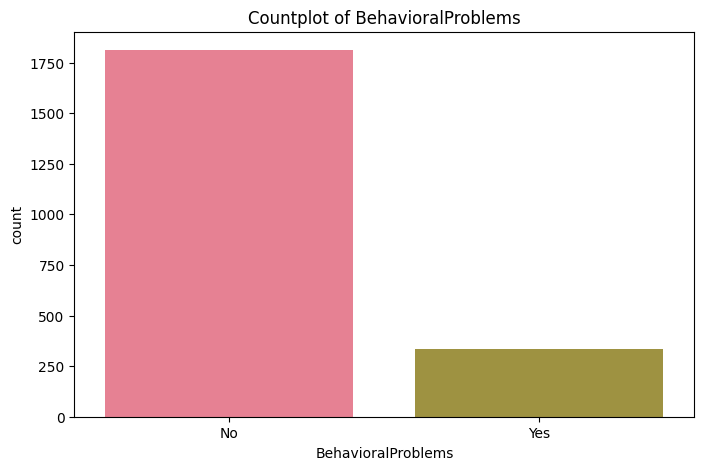

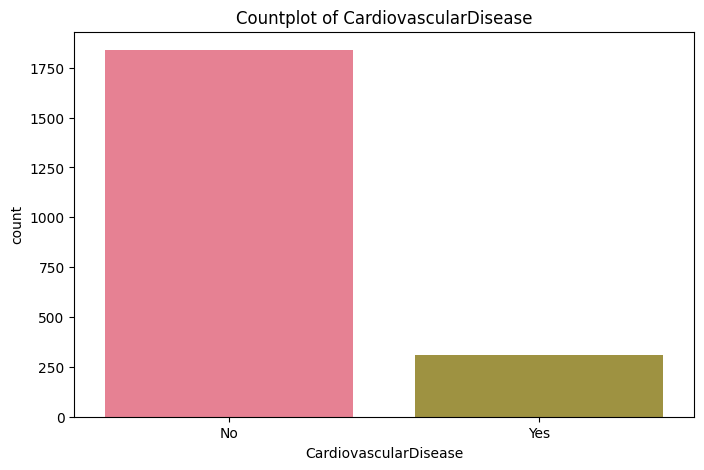

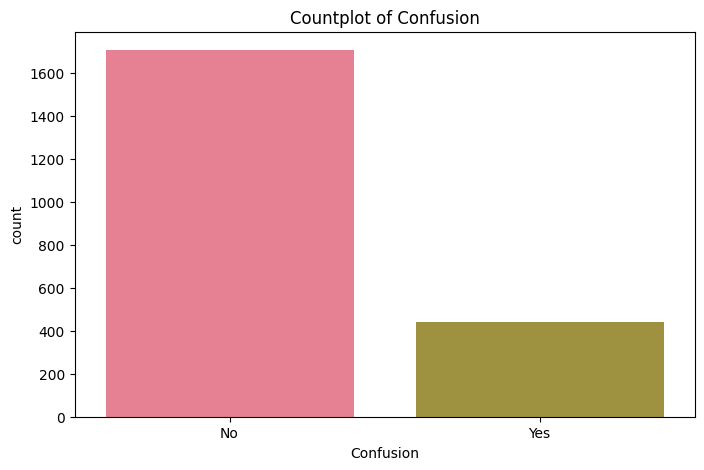

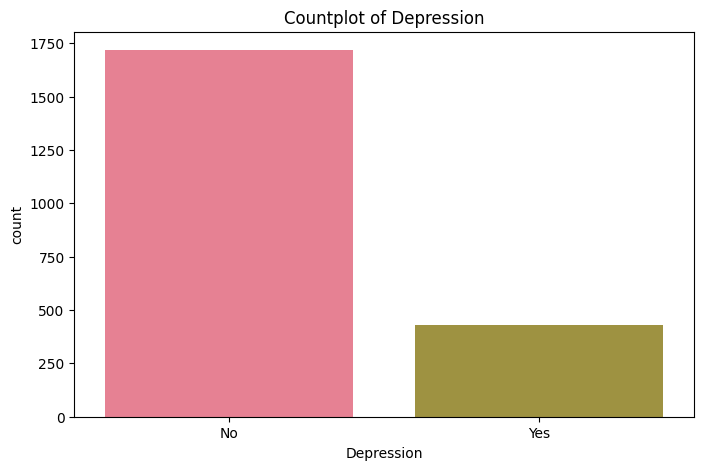

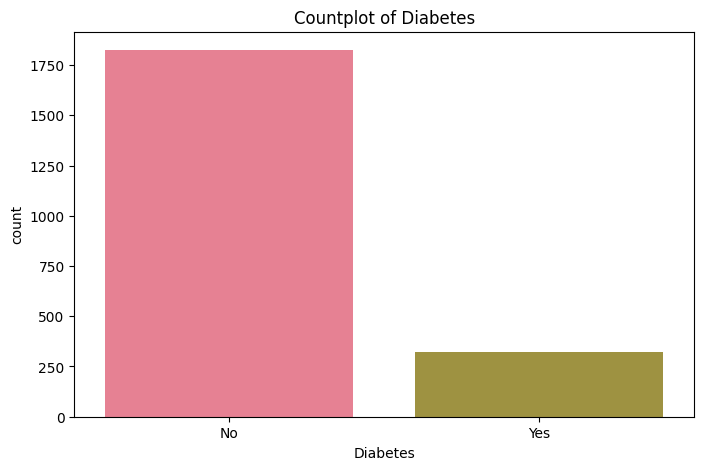

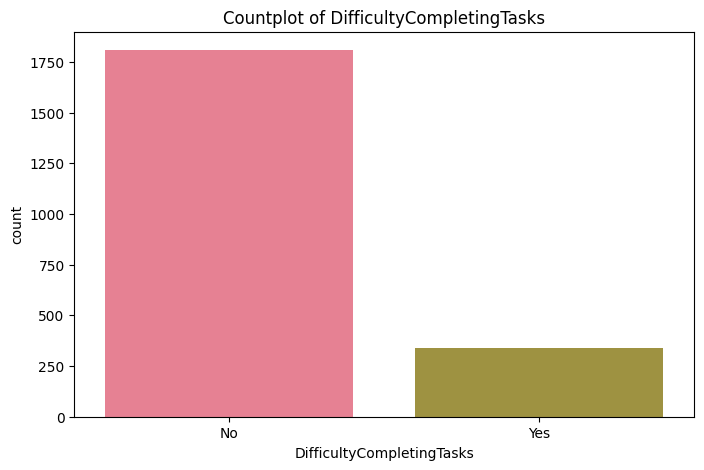

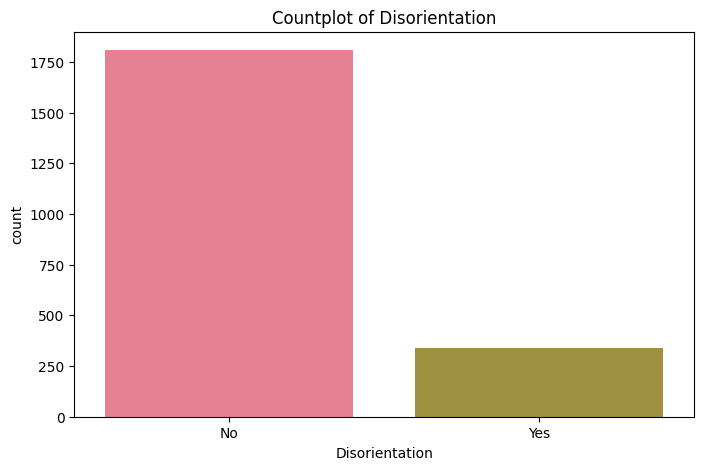

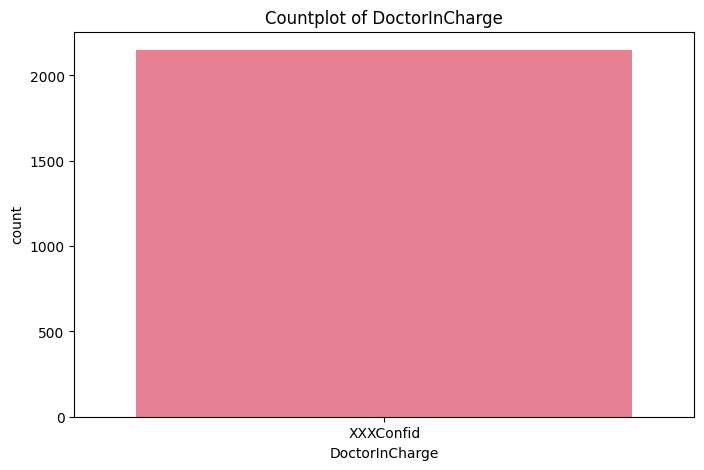

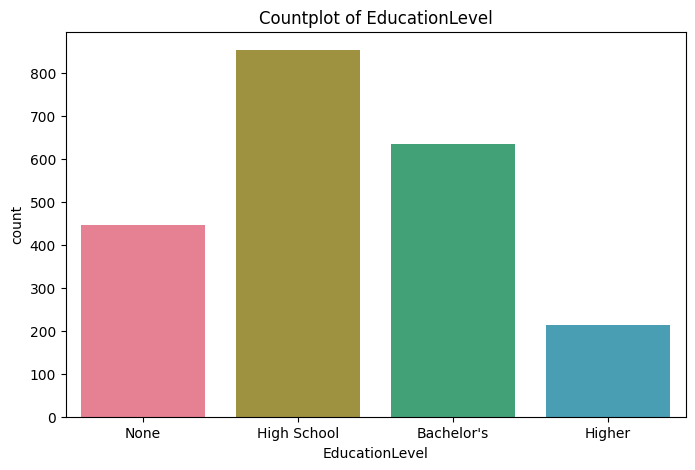

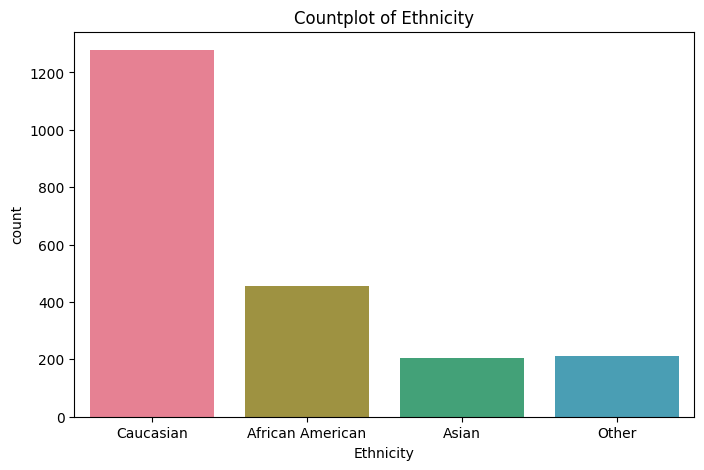

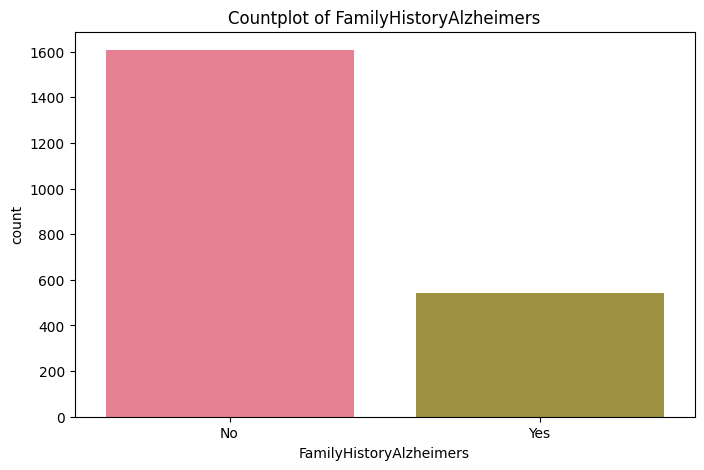

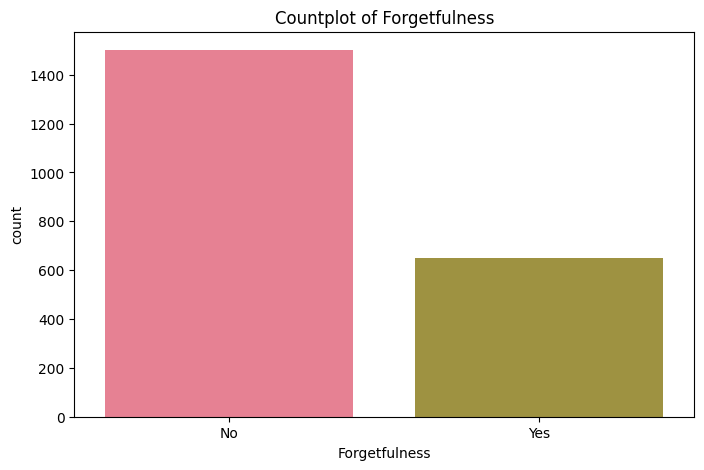

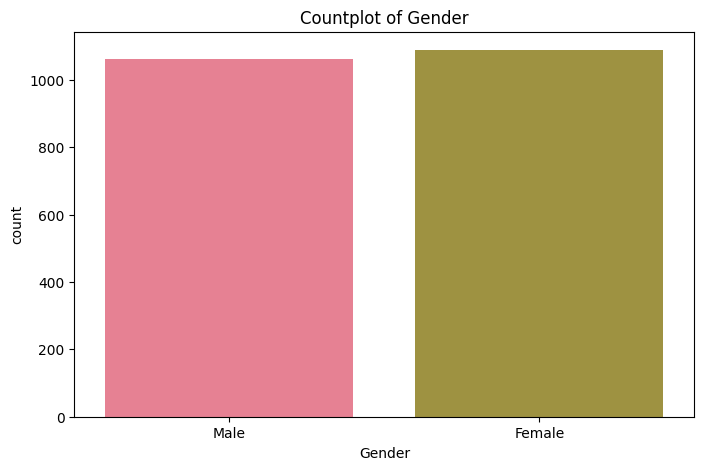

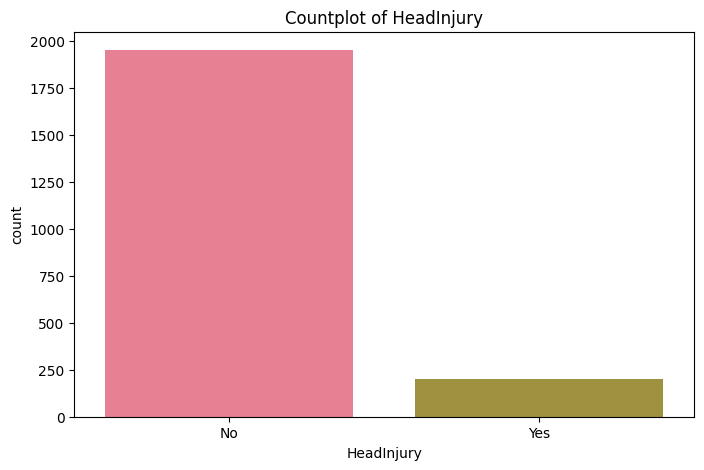

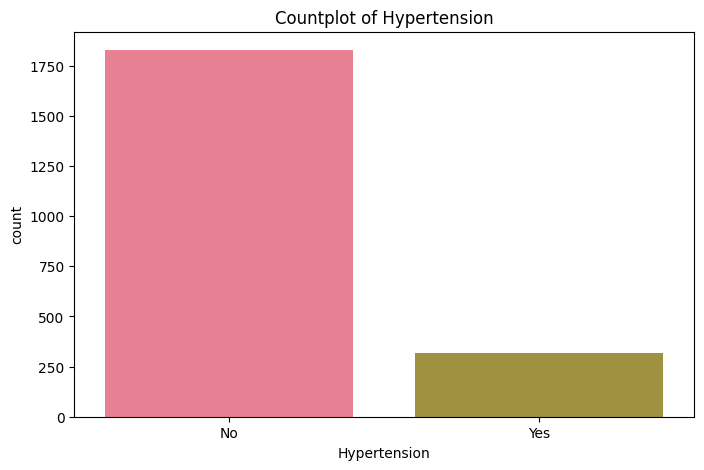

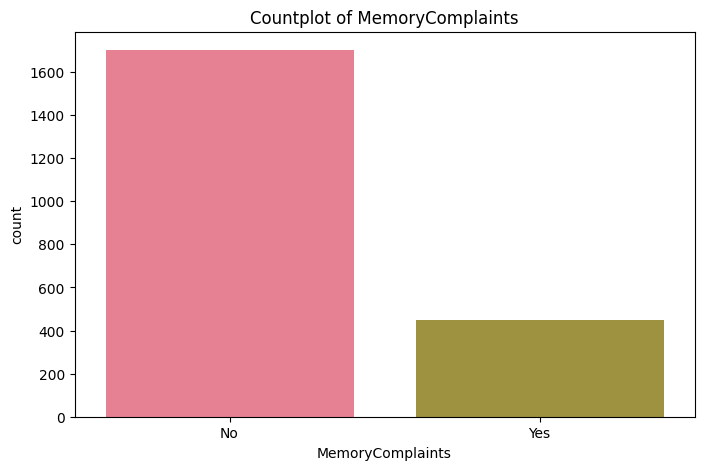

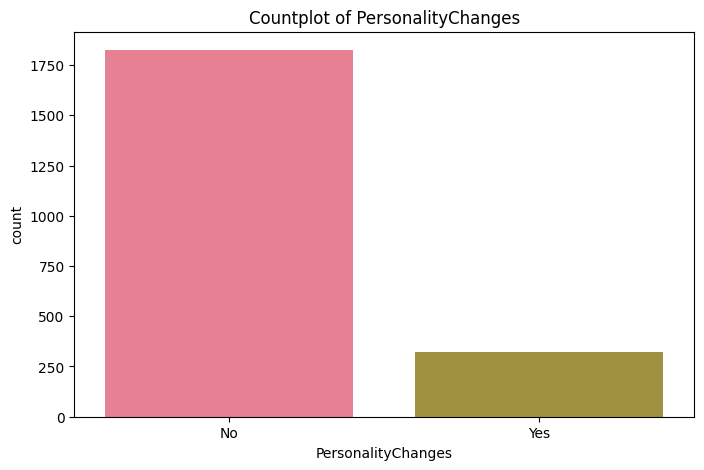

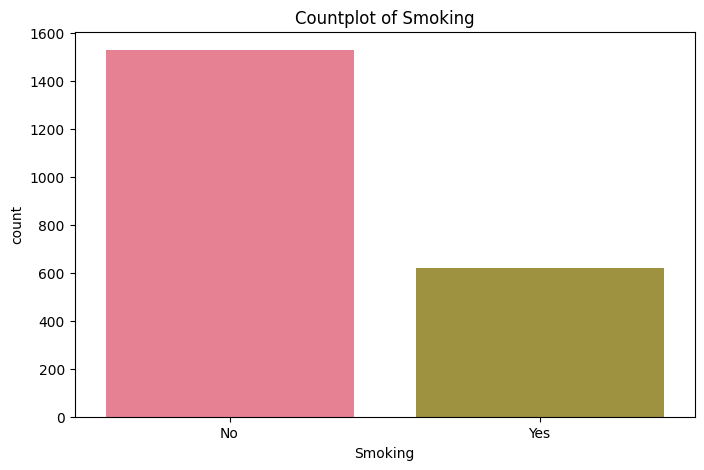

In [9]:
# Generate a smooth color palette with 5 colors
palette = sns.color_palette('husl', 5)

# Custom labels for the categorical columns
custom_labels = {
    'Gender': ['Male', 'Female'],
    'Ethnicity': ['Caucasian', 'African American', 'Asian', 'Other'],
    'EducationLevel': ['None', 'High School', 'Bachelor\'s', 'Higher'],
    'Smoking': ['No', 'Yes'],
    'FamilyHistoryAlzheimers': ['No', 'Yes'],
    'CardiovascularDisease': ['No', 'Yes'],
    'Diabetes': ['No', 'Yes'],
    'Depression': ['No', 'Yes'],
    'HeadInjury': ['No', 'Yes'],
    'Hypertension': ['No', 'Yes'],
    'MemoryComplaints': ['No', 'Yes'],
    'BehavioralProblems': ['No', 'Yes'],
    'Confusion': ['No', 'Yes'],
    'Disorientation': ['No', 'Yes'],
    'PersonalityChanges': ['No', 'Yes'],
    'DifficultyCompletingTasks': ['No', 'Yes'],
    'Forgetfulness': ['No', 'Yes']
}

categorical_columns = [col for col in categorical_columns if col in data.columns]

# Plot countplots for each categorical column
for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=col, palette=palette)
    plt.title(f'Countplot of {col}')
    
    # Directly set custom labels
    if col in custom_labels:
        labels = custom_labels[col]
        ticks = range(len(labels))
        plt.xticks(ticks=ticks, labels=labels)
    
    plt.show() # 17 total count plot charts

### Categorical Features Visualization Summary
- The dataset predominantly consists of individuals **without disease or other health issues**.
- **Caucasian** is the most represented ethnicity.
- **High School** constitude the largest educational group, followed by **Bachelor's** degree.
- Both **Female** & **Male** are closely equally represented in the dataset.

### Distribution of Numerical Features (Histograms)

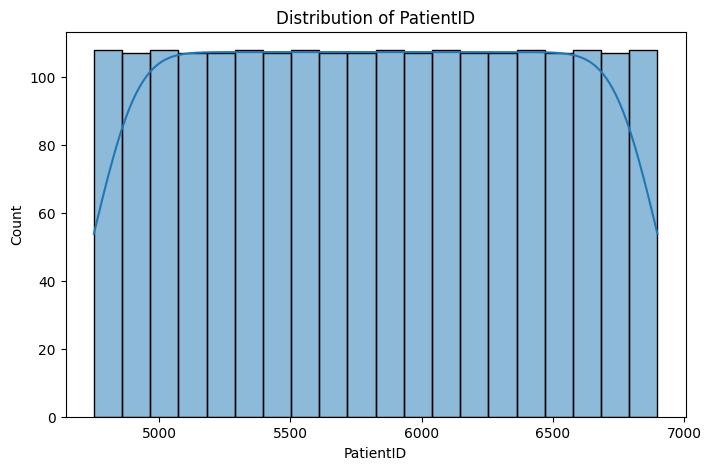

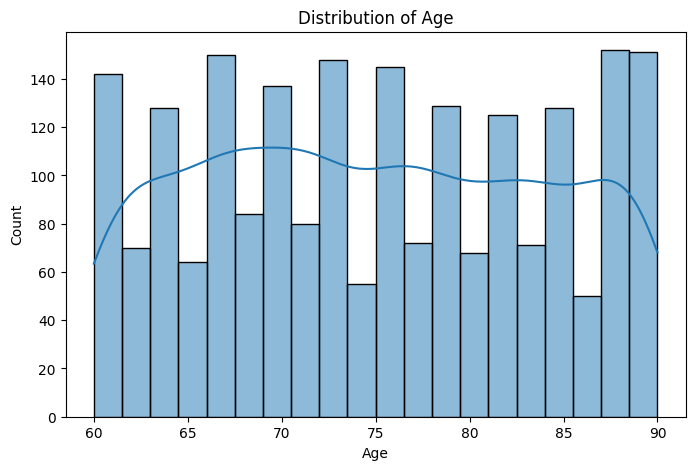

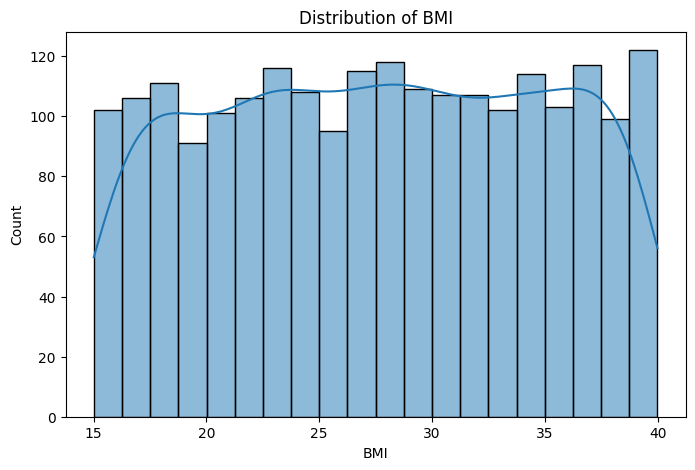

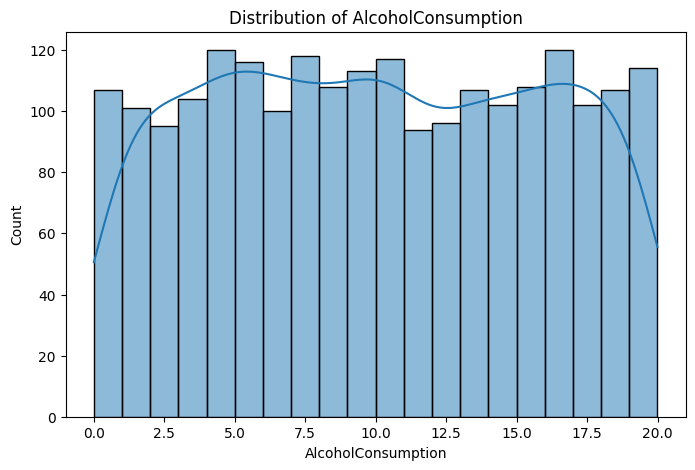

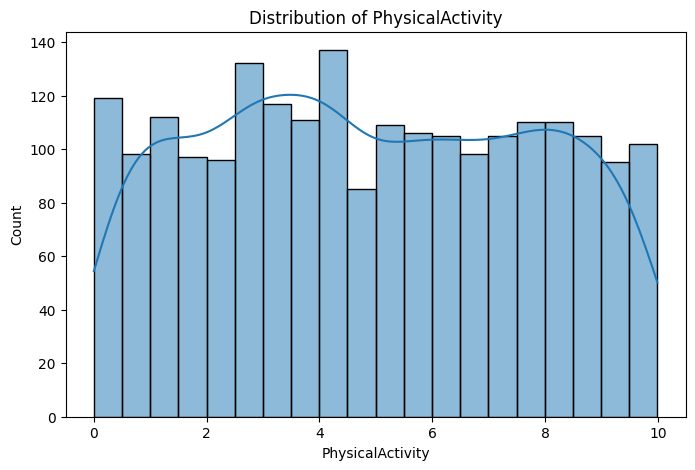

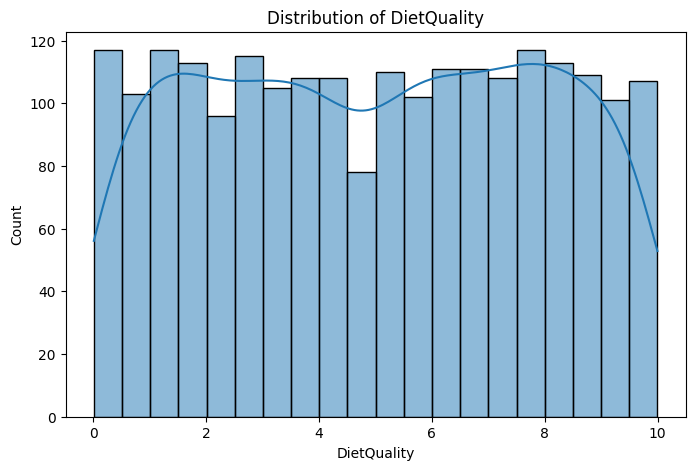

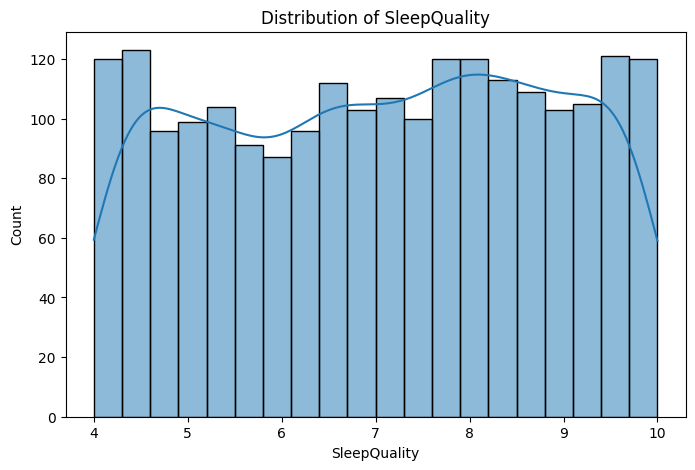

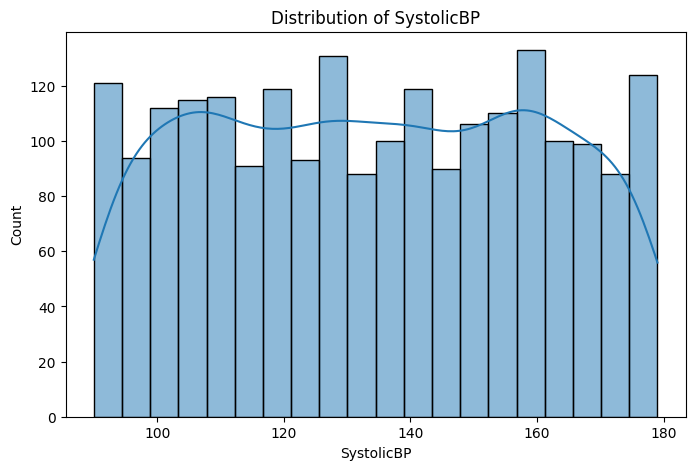

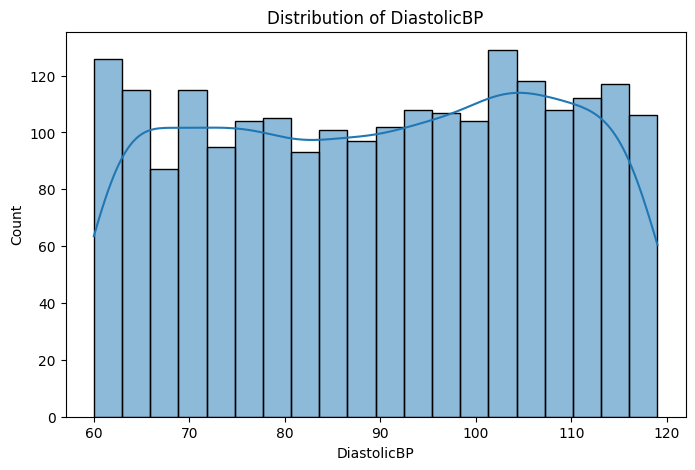

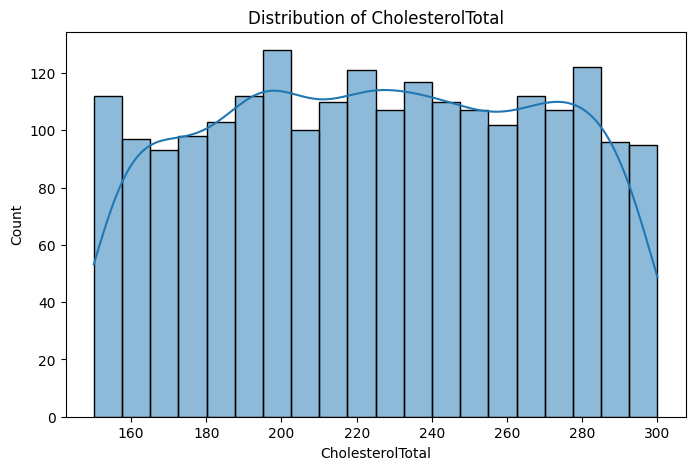

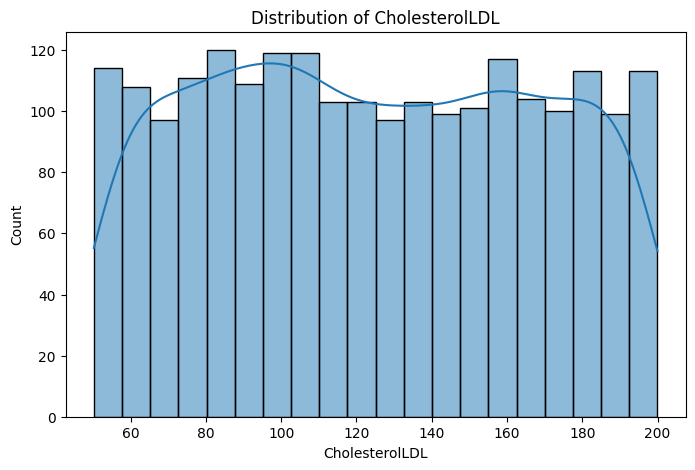

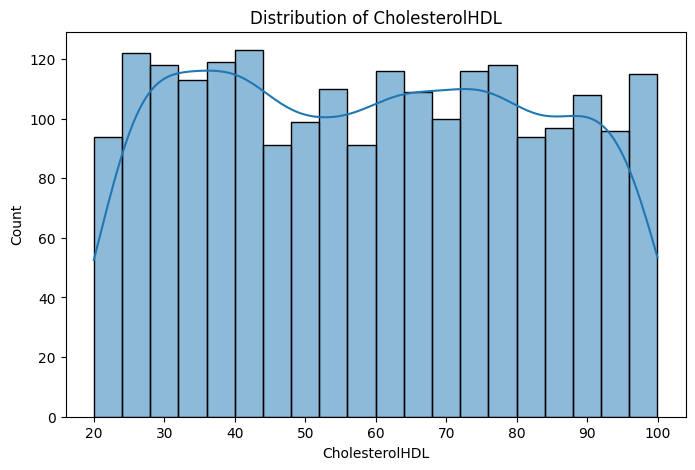

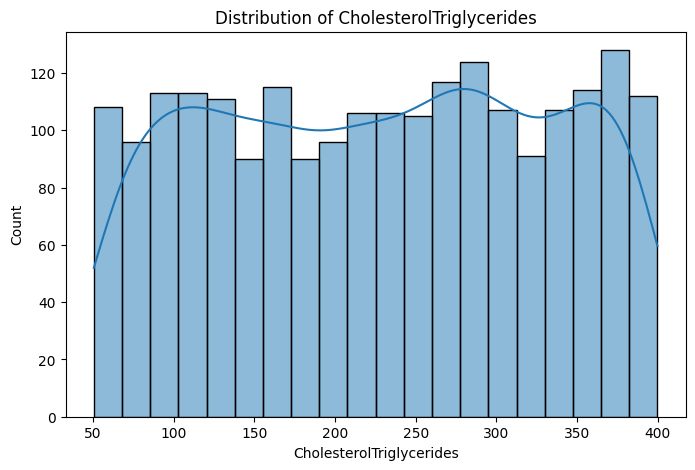

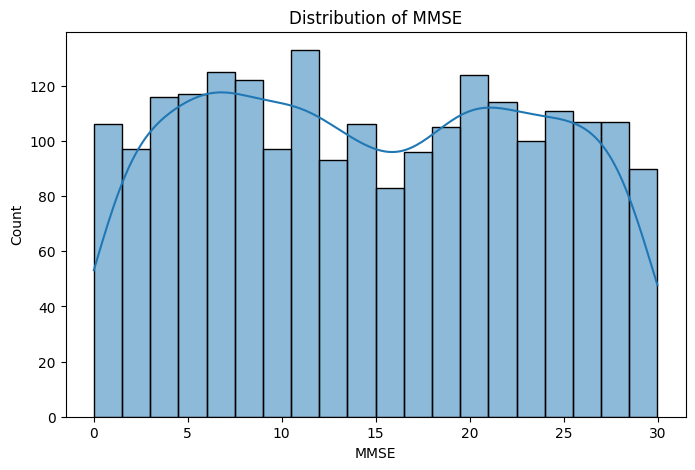

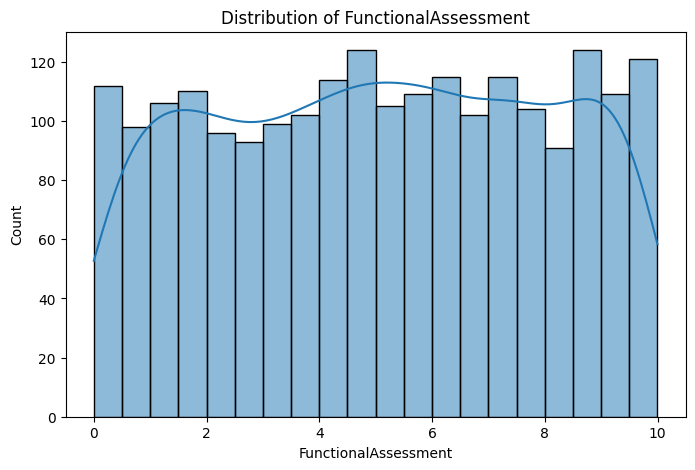

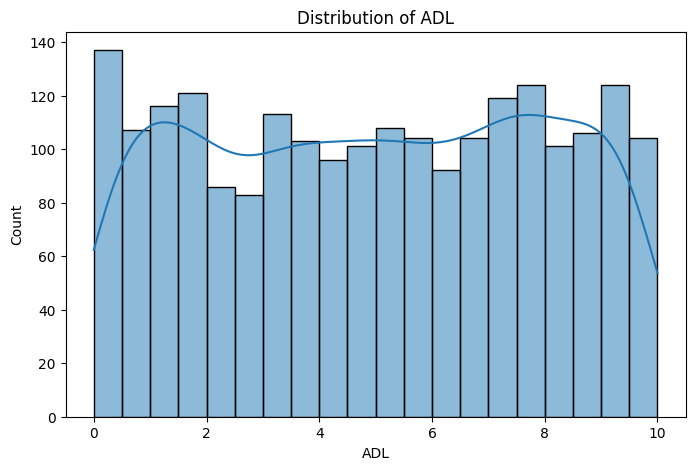

In [10]:
# Plot histogram for each numerical column
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=data, x=col, kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.show()

### Numerical Feature Distribution Summary
- Most features show a **fairly uniform** distribution
- The "MMSE" (Mini-Mental State Examination) distribution appears to be **Bimodal**, indicating two 2 distinct groups within the data.

### Distribution of the Target Variable (*Diagnosis*)

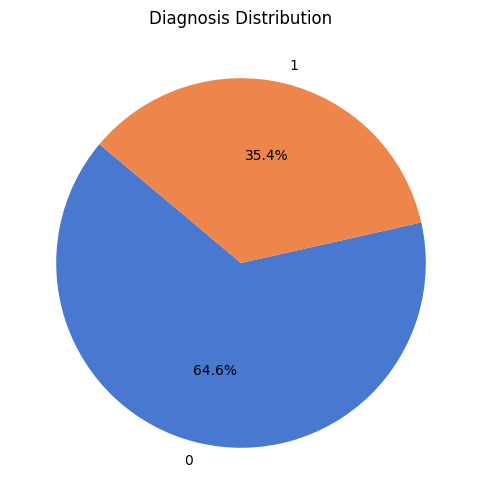

In [11]:
# Define the Response categories and count occurances
categories = [0, 1]
counts = data.Diagnosis.value_counts().tolist()

# Color palette
colors = sns.color_palette("muted")

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=categories, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Diagnosis Distribution')
plt.show()

### Target Value Distribution Summary
- The target value is **moderately imbalanced** with ~65% of instances being 0 and ~35% being 1.
- This confirms our previous observation in the *Categorical Feature Distribution Countplots* that the data is **skewed heavily** towards individuals **without Alzheimer's Disease**.

### Let's Dig Deeper into 'Age', 'Gender', 'Ethnicity', and 'Educational Level' to better understand the effects of AD...
- And to verify if our hypothesis (stated on the README.MD) holds true. Does educational level have any affects on AD?

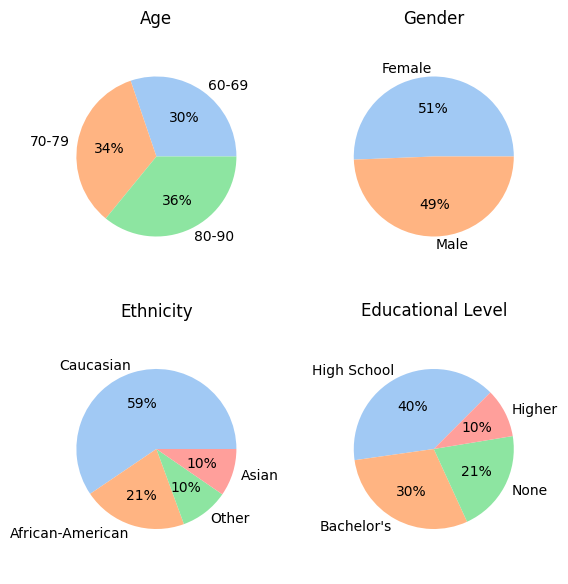

In [12]:
# Define colors palette
colors = sns.color_palette('pastel')[0:5]

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(6, 6))

# Pie chart for Age
data['bins'] = pd.cut(data['Age'], bins=[60, 69, 79, 90], labels=["60-69", "70-79", "80-90"])
axs[0, 0].pie(data.groupby('bins').size(), labels=data.groupby('bins').size().index, colors=colors, autopct='%.0f%%',radius=0.8)
axs[0, 0].set_title("Age")

# Pie chart for Gender
axs[0, 1].pie(data['Gender'].value_counts(), labels=['Female', 'Male'], colors=colors, autopct='%.0f%%',radius=0.8)
axs[0, 1].set_title("Gender")

# Pie chart for Ethnicity
axs[1, 0].pie(data['Ethnicity'].value_counts(), labels=['Caucasian', 'African-American', 'Other', 'Asian'], colors=colors, autopct='%.0f%%',radius=0.8)
axs[1, 0].set_title("Ethnicity")

# Pie chart for Educational Level
axs[1, 1].pie(data['EducationLevel'].value_counts(), startangle=45, labels=['High School', "Bachelor's", 'None', 'Higher'], colors=colors, autopct='%.0f%%',radius=0.8)
axs[1, 1].set_title("Educational Level")

# Remove the 'bins' column from the data
data.drop(['bins'], axis=1, inplace=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

### So far, we can confirm some of the previously stated points:
- The age pie chart suggest the highest proportion of patients falls within the 80-90 age group.
- Gender distribution is balanced.
- In terms of ethnicity, Caucasian patients are the most prevalent.
- The most common educational levels are high school followed by bachelor's degrees.

### Check the Distribution of AD Diagnosed patients based on 'EducationLevel', 'Ethnicity' and 'FamilyHistoryAlzheimers'
- (When'Diagnosis=1')

**Assumptions** (_Hypothesis_)

1. When symptoms appear after the age of 60, it implies late-onset AD which is the most common form of the disease. Family history of dementia is a known risk factor for developing late-onset AD. Therefore, I expect that family history is a factor contributing to AD. Therefore, it could be highly positively correlated with AD positives. Is that true, given the dataset?

2. Does education level affect AD?

In [13]:
def create_diagnosis_dataframe(column_name, index_mapping):
    total = data[column_name].value_counts().sort_index()
    total.name='Total'
    diagnosis1 = data.groupby(column_name)['Diagnosis'].sum()
    percentage = diagnosis1 / total * 100
    percentage.name = 'Diagnosis, %'
    
    df = pd.concat([total, diagnosis1, percentage], axis=1)
    df['Total, %'] = 100  
    df.index = index_mapping
    return df
    

print("Education Level DataFrame:")
df_educ=create_diagnosis_dataframe('EducationLevel', ['None', 'Highschool', "Bachelor's", 'Higher'])
print(df_educ,'\n')

print("Ethnicity DataFrame:")
df_ethn=create_diagnosis_dataframe('Ethnicity', ['Caucasian', 'African-American', 'Asian', 'Other'])
print(df_ethn,'\n')

print("Family History of Alzheimer's DataFrame:")
df_famh=create_diagnosis_dataframe('FamilyHistoryAlzheimers', ['Yes', 'No'])
print(df_famh,'\n')

Education Level DataFrame:
            Total  Diagnosis  Diagnosis, %  Total, %
None          446        174     39.013453       100
Highschool    854        302     35.362998       100
Bachelor's    636        217     34.119497       100
Higher        213         67     31.455399       100 

Ethnicity DataFrame:
                  Total  Diagnosis  Diagnosis, %  Total, %
Caucasian          1278        463     36.228482       100
African-American    454        146     32.158590       100
Asian               206         84     40.776699       100
Other               211         67     31.753555       100 

Family History of Alzheimer's DataFrame:
     Total  Diagnosis  Diagnosis, %  Total, %
Yes   1607        583     36.278780       100
No     542        177     32.656827       100 



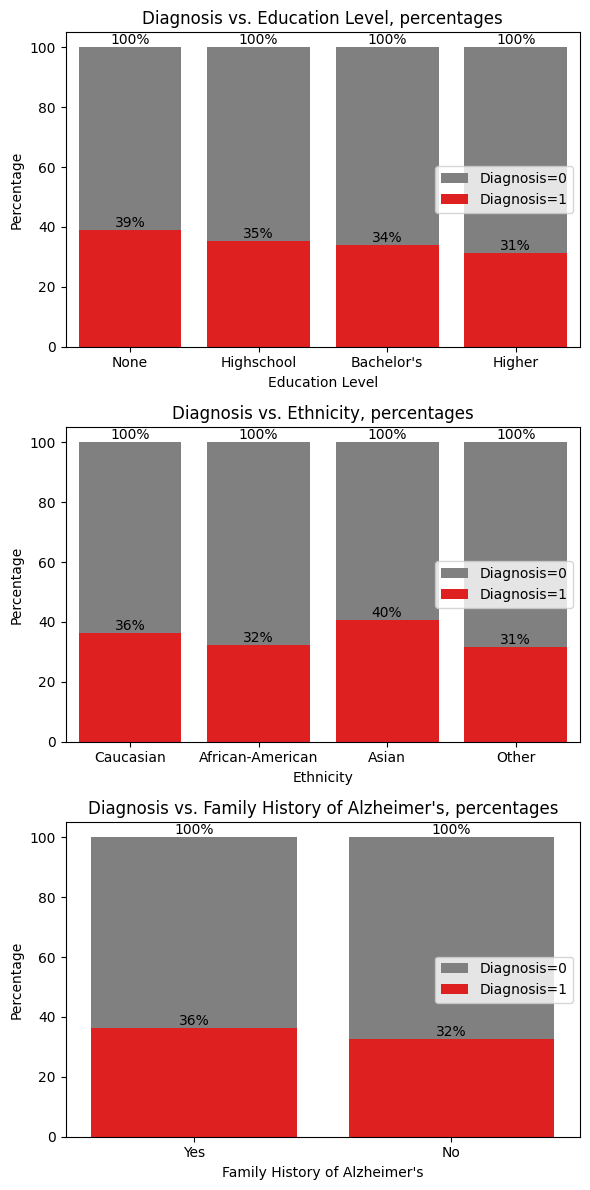

In [14]:
def plot_diagnosis_vs_category(ax, df, category_name):
    sns.barplot(x=df.index, y='Total, %', data=df, color='gray', label='Diagnosis=0', ax=ax, ci=None)
    sns.barplot(x=df.index, y='Diagnosis, %', data=df, color='red', label='Diagnosis=1', ax=ax, ci=None)
    ax.set_title(f"Diagnosis vs. {category_name}, percentages")
    ax.set_xlabel(category_name)
    ax.set_ylabel('Percentage')
    ax.legend()
    for container in ax.containers:
        labels = [f'{int(v.get_height())}%' for v in container]
        ax.bar_label(container, labels=labels, label_type='edge')

fig, axs = plt.subplots(3, 1, figsize=(6, 12))  # Adjust figure size to fit the bars better

plot_diagnosis_vs_category(axs[0], df_educ, "Education Level")
plot_diagnosis_vs_category(axs[1], df_ethn, "Ethnicity")
plot_diagnosis_vs_category(axs[2], df_famh, "Family History of Alzheimer's")
plt.tight_layout()
plt.show()

### Summary of the AD Diagnosed Patients

**Diagnosis vs. Education Level:** A gentle decline along the x-axis indicates that higher levels of education may be associated with a reduced risk of Alzheimer's Disease (AD).

**Diagnosis vs. Ethnicity:** The data indicates a marginally increased risk of Alzheimer's Disease (AD) for individuals of Asian descent.

**Diagnosis vs. Family History of Alzheimer's:** The analysis shows no significant effect, suggesting that family history does not seem to influence the risk of Alzheimer's Disease (AD) in this dataset. 😯 Surprisingly and contrary to expectations 😯, there is ~4% difference in AD-diagnosed patients with and without Family History Alzheimer's.

### Double-check these findings statistically with chi-square test

In [15]:
import scipy.stats as stats

def calculate_chi_square(data, description):
    # Calculate the 'Not' column
    data['Not'] = data['Total'] - data['Diagnosis']
    
    # Create the observed values array
    observed = np.array(data[['Diagnosis', 'Not']].values)
    
    # Perform the chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(observed)
    
    # Print the p-value with the description
    print(f"{description} p-value: {round(p,3)}")

calculate_chi_square(df_educ, 'EducationLevel')
calculate_chi_square(df_ethn, 'Ethnicity')
calculate_chi_square(df_famh, 'FamilyHistoryAlzheimers')

EducationLevel p-value: 0.217
Ethnicity p-value: 0.098
FamilyHistoryAlzheimers p-value: 0.141


### Summary of chi-square test:
The null hypothesis (H₀): No significant association between the two categorical variables being tested.

- p-value of 0.217:

This p-value is greater than 0.05, which means there’s no strong evidence to suggest that Education Level and Diagnosis are related. In other words, education level doesn't significantly affect the likelihood of having a diagnosis based on this data.


- 💥 p-value of 0.098 💥: 

This p-value is greater than alpha level of 0.05 but less than 0.10. This suggests that there is a weak evidence against the null hypothesis which implies that there might be some association between Ethnicity and Diagnosis.

- p-value of 0.141:

Similar to Ethnicity, this p-value suggests that there’s a weak association between Family History of Alzheimer's and Diagnosis, but it’s not significant at the usual cutoff of 0.05.

**Conclusion:**

All p-values are above 0.05, so there isn’t strong evidence to suggest a significant relationship between these factors and the diagnosis in our dataset.

### Explore Correlations

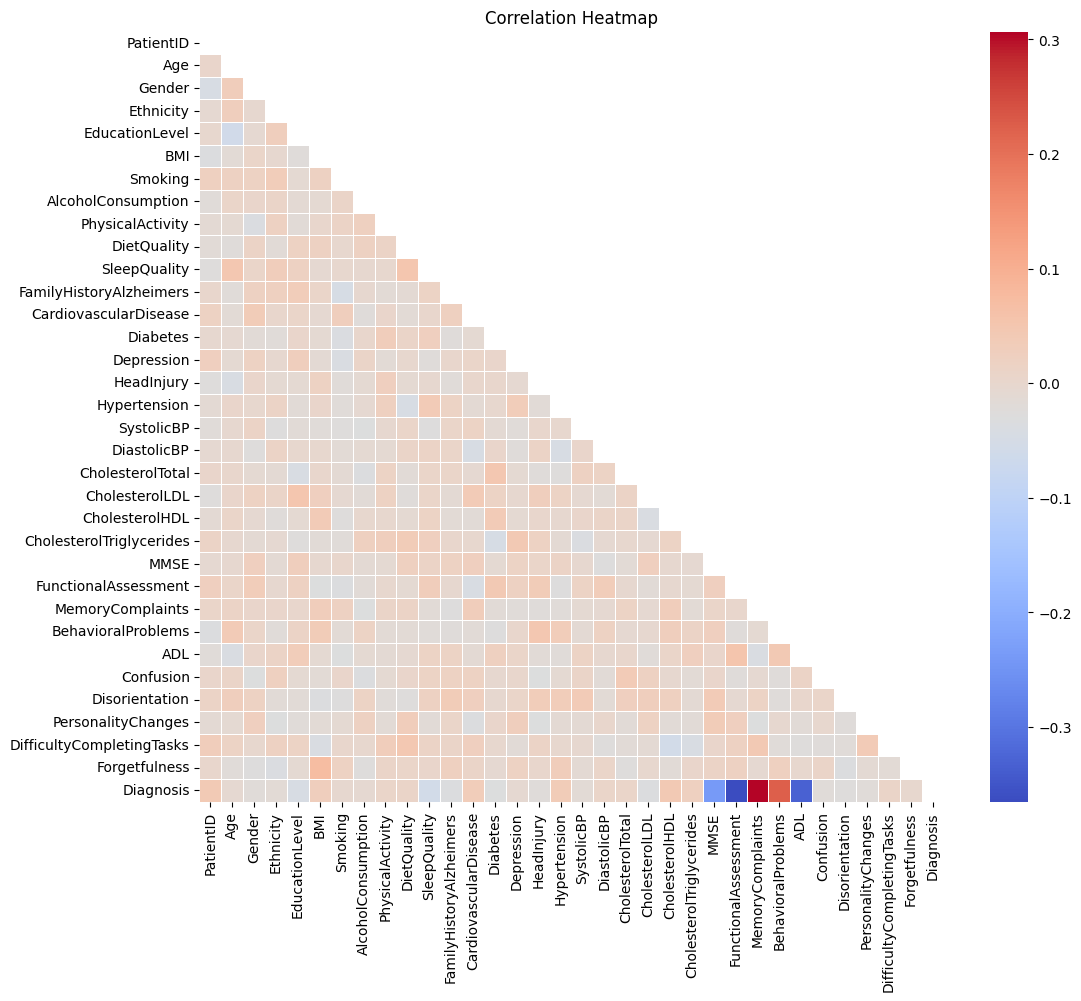

In [16]:
# Select only numeric columns for correlation analysis
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlations Explained:
- The heatmap suggest that features do not have any strong correlations among themselves. But, 5 columns show some correlation **with the target variable**. These features are:
> MMSE, Functional Assessment, Memory Complains, Behavioral Problems, ADL

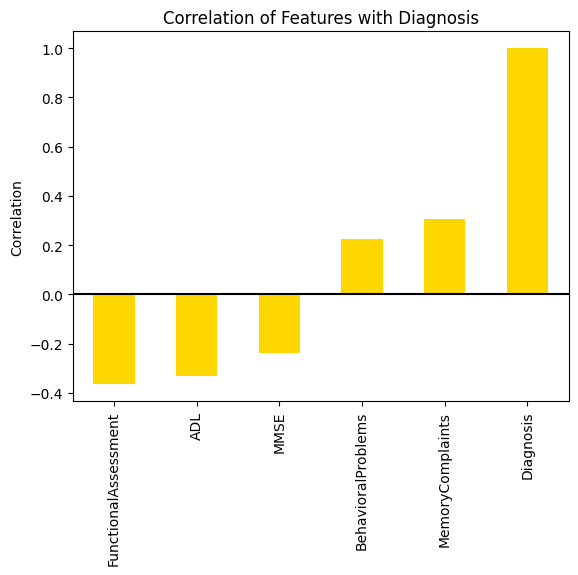

In [17]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Correlation of features with Diagnosis
corr_matrix = numeric_data.corr()['Diagnosis']

# Keep only features with absolute correlation > 0.1
heatcol = corr_matrix[corr_matrix.abs() > 0.1].index

# Plot correlations with Diagnosis
numeric_data[heatcol].corr()['Diagnosis'].sort_values().plot(kind='bar', color='gold')

plt.axhline(0, color='black')
plt.title("Correlation of Features with Diagnosis")
plt.ylabel("Correlation")
plt.show()

### Correlations Explained (2):

As observed, there are five columns correlated with the target variable.
- Three numerical features: **Functional Assessment**, **ADL** (Activities of Daily Living), and **MMSE** (Mini-Mental State Examination) are negatively correlated with the **diagnosis of Alzheimer's disease**. This indicates that lower scores in these assessments are associated with a higher likelihood of an AD.
- Two categorical variables: **Behavioral Problems** and **Memory Complaints** are positively correlated with the **diagnosis**. This means the presence of these issues is associated with a higher likelihood of an Alzheimer's diagnosis, highlighting their significance in the diagnostic process.

In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


<h1><center>Data Pre-Processing</center></h1>

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Data Cleaning

In [20]:
# Drop unnecessary columns
data = data.drop(["PatientID", "DoctorInCharge"], axis=1, errors="ignore")

### Convert Categorical Features to Dummy Variables

In [21]:
categorical_columns = [col for col in categorical_columns if col in data.columns]

data = pd.get_dummies(data, columns=categorical_columns, prefix=categorical_columns)

boo = data.columns[data.dtypes == bool].tolist()
data[boo] = data[boo].astype('Int64')

### Prepare Data for Training
- Feature and Target Separation
- Train-Test Split

In [22]:
# Split data into features and target
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

In [23]:
# stratified split keeps the class distribution similar in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Feature Standardization
Numerical features were standardized using StandardScaler before training the models.

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h1><center>Baseline Models Trained on Real Data</center></h1>

After preprocessing the dataset, three baseline machine learning models were trained on the real clinical data: Logistic Regression, Random Forest, and a simple Neural Network. These models serve as the reference point for the study and allow us to evaluate how well classification can be performed using the original dataset.

Their performance is assessed using standard classification metrics, including accuracy, precision, recall, and F1-score. In addition, confusion matrices are used to better understand the prediction patterns of each model before introducing synthetic data into the experimental workflow.

In [25]:
# Import necessary Machine Learning libraries
from tabulate import tabulate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

In [26]:
# Define baseline models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

In [27]:
# Train baseline models on real data
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []
real_confusion_matrices = {}

for name, model in models.items():
    model_real = clone(model)
    model_real.fit(X_train_scaled, y_train)

    y_pred_real = model_real.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_real)
    prec = precision_score(y_test, y_pred_real, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_real, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_real, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Train Data": "Real",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    real_confusion_matrices[name] = confusion_matrix(y_test, y_pred_real)

real_results_df = pd.DataFrame(results)
real_results_df

,Model,Train Data,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Real,0.826625,0.827366,0.826625,0.826962
1,Random Forest,Real,0.947368,0.947492,0.947368,0.947420
2,Neural Network,Real,0.786378,0.786814,0.786378,0.786588


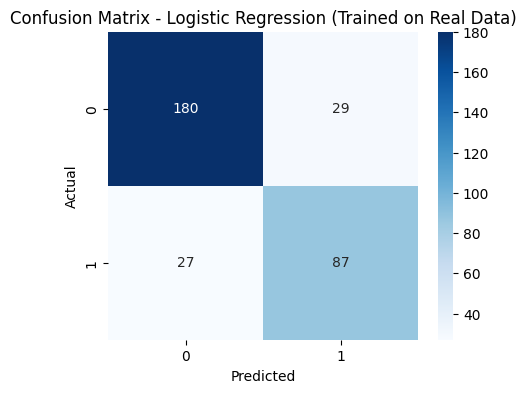

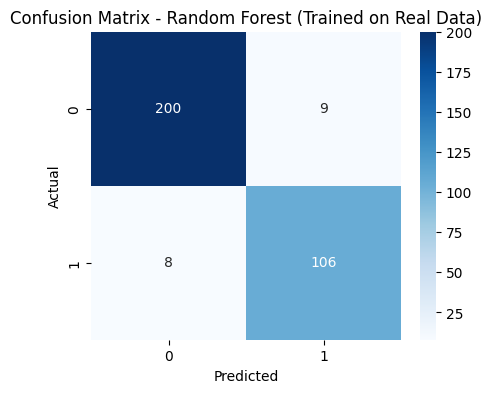

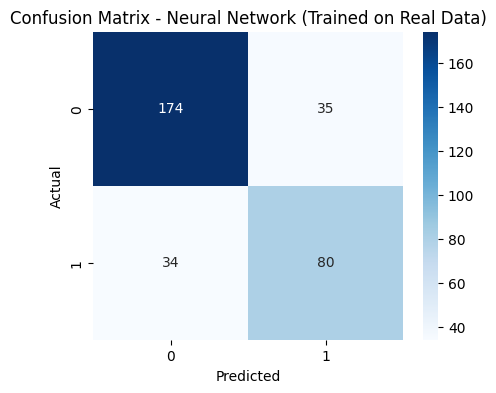

In [28]:
# Show confusion matrices for models trained on real data
for name, cm in real_confusion_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (Trained on Real Data)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

<h1><center>Variational Autoencoder for Synthetic Data Generation</center></h1>

In this section, a Conditional Variational Autoencoder (CVAE) is used to learn the underlying distribution of the real training data and generate synthetic patient records. The purpose of this step is to investigate whether artificially generated healthcare data can preserve the important statistical patterns needed for predictive modeling.

Once the CVAE is trained, new synthetic samples are produced from the learned latent space. These synthetic records are later used to train the same baseline classification models, making it possible to compare their performance against models trained on real data.

In [29]:
# Prepare Data for VAE
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

y_train_np = y_train.to_numpy().astype(np.int64)
y_test_np = y_test.to_numpy().astype(np.int64)

input_dim = X_train_scaled.shape[1]
latent_dim = 8
hidden_dim = 64
num_classes = len(np.unique(y_train_np))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)

vae_dataset = TensorDataset(X_train_tensor, y_train_tensor)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

print("Input dimension:", input_dim)
print("Training samples for VAE:", len(vae_dataset))
print("Number of classes:", num_classes)

Input dimension: 53
Training samples for VAE: 1826
Number of classes: 2


In [30]:
import torch.nn as nn
import torch.nn.functional as F

class ConditionalVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes):
        super(ConditionalVAE, self).__init__()

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(input_dim + num_classes, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim + num_classes, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, y):
        y_onehot = F.one_hot(y, num_classes=self.num_classes).float()
        h = torch.cat([x, y_onehot], dim=1)
        h = torch.relu(self.fc1(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_onehot = F.one_hot(y, num_classes=self.num_classes).float()
        h = torch.cat([z, y_onehot], dim=1)
        h = torch.relu(self.fc2(h))
        return self.fc3(h)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y)
        return x_recon, mu, logvar

In [31]:
def vae_loss_function(recon_x, x, mu, logvar, beta=0.1):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

vae = ConditionalVAE(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_classes=num_classes
).to(device)

optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)

num_epochs = 100
beta = 0.1
vae_history = []

vae.train()
for epoch in range(num_epochs):
    epoch_total = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0

    for xb, yb in vae_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar = vae(xb, yb)
        loss, recon_loss, kl_loss = vae_loss_function(x_recon, xb, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        epoch_total += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    vae_history.append({
        "epoch": epoch + 1,
        "total_loss": epoch_total / len(vae_loader),
        "reconstruction_loss": epoch_recon / len(vae_loader),
        "kl_loss": epoch_kl / len(vae_loader)
    })

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"Total: {vae_history[-1]['total_loss']:.4f} | "
            f"Recon: {vae_history[-1]['reconstruction_loss']:.4f} | "
            f"KL: {vae_history[-1]['kl_loss']:.4f}"
        )

vae_history_df = pd.DataFrame(vae_history)
vae_history_df.tail()

Using device: cpu
Epoch 010/100 | Total: 0.8254 | Recon: 0.7355 | KL: 0.8988
Epoch 020/100 | Total: 0.7376 | Recon: 0.6242 | KL: 1.1339
Epoch 030/100 | Total: 0.6889 | Recon: 0.5689 | KL: 1.1996
Epoch 040/100 | Total: 0.6625 | Recon: 0.5382 | KL: 1.2433
Epoch 050/100 | Total: 0.6454 | Recon: 0.5175 | KL: 1.2790
Epoch 060/100 | Total: 0.6330 | Recon: 0.5039 | KL: 1.2914
Epoch 070/100 | Total: 0.6256 | Recon: 0.4925 | KL: 1.3316
Epoch 080/100 | Total: 0.6175 | Recon: 0.4829 | KL: 1.3458
Epoch 090/100 | Total: 0.6086 | Recon: 0.4716 | KL: 1.3692
Epoch 100/100 | Total: 0.6035 | Recon: 0.4642 | KL: 1.3932


,epoch,total_loss,reconstruction_loss,kl_loss
95,96,0.604125,0.466990,1.371350
96,97,0.603196,0.466476,1.367204
97,98,0.602225,0.465266,1.369592
98,99,0.603626,0.465487,1.381387
99,100,0.603514,0.464193,1.393204


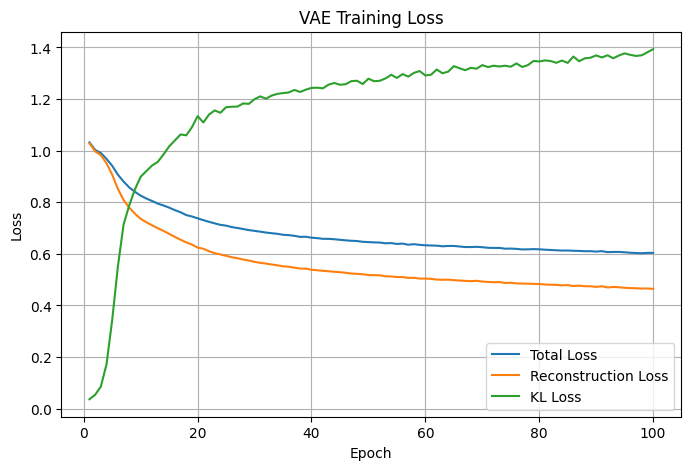

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(vae_history_df["epoch"], vae_history_df["total_loss"], label="Total Loss")
plt.plot(vae_history_df["epoch"], vae_history_df["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(vae_history_df["epoch"], vae_history_df["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Synthetic Data Generation

After training the CVAE, synthetic patient records are generated from the learned latent space. These synthetic samples are then converted into a structured tabular format and used for further classification experiments.

In [34]:
# Generate synthetic data with trained VAE
vae.eval()

n_synthetic = len(X_train_scaled)
samples_per_class = n_synthetic // num_classes

synthetic_data_list = []
synthetic_labels_list = []

with torch.no_grad():
    for class_label in range(num_classes):
        y_synth = torch.full((samples_per_class,), class_label, dtype=torch.long).to(device)
        z = torch.randn(samples_per_class, latent_dim).to(device)

        x_synth = vae.decode(z, y_synth)
        x_synth = x_synth.cpu().numpy()

        synthetic_data_list.append(x_synth)
        synthetic_labels_list.append(np.full(samples_per_class, class_label))

X_synthetic = np.vstack(synthetic_data_list)
y_synthetic = np.concatenate(synthetic_labels_list)

print("Synthetic data shape:", X_synthetic.shape)
print("Synthetic labels shape:", y_synthetic.shape)
print("Class distribution:", np.bincount(y_synthetic))

Synthetic data shape: (1826, 53)
Synthetic labels shape: (1826,)
Class distribution: [913 913]


In [35]:
# Add remaining samples if division was not exact
remaining = len(X_train_scaled) - len(X_synthetic)

if remaining > 0:
    with torch.no_grad():
        extra_labels = np.random.choice(np.arange(num_classes), size=remaining)
        y_extra = torch.tensor(extra_labels, dtype=torch.long).to(device)
        z_extra = torch.randn(remaining, latent_dim).to(device)

        x_extra = vae.decode(z_extra, y_extra).cpu().numpy()

    X_synthetic = np.vstack([X_synthetic, x_extra])
    y_synthetic = np.concatenate([y_synthetic, extra_labels])

print("Final synthetic data shape:", X_synthetic.shape)
print("Final synthetic labels shape:", y_synthetic.shape)
print("Final class distribution:", np.bincount(y_synthetic))

Final synthetic data shape: (1826, 53)
Final synthetic labels shape: (1826,)
Final class distribution: [913 913]


In [36]:
# Convert synthetic data to DataFrame
X_synthetic_df = pd.DataFrame(X_synthetic, columns=X.columns)
y_synthetic_series = pd.Series(y_synthetic, name="Diagnosis")

synthetic_dataset = X_synthetic_df.copy()
synthetic_dataset["Diagnosis"] = y_synthetic_series

synthetic_dataset.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,...,HeadInjury_1,Hypertension_0,Hypertension_1,MemoryComplaints_0,MemoryComplaints_1,PersonalityChanges_0,PersonalityChanges_1,Smoking_0,Smoking_1,Diagnosis
0,0.503976,-0.140448,-0.021551,0.050739,0.091111,0.128503,-0.034449,0.408653,-0.005003,0.028260,...,-0.231959,-0.931251,0.927752,0.695396,-0.708858,0.351590,-0.339320,-0.334010,0.372733,0
1,0.052281,0.338454,0.244588,0.106047,-0.364548,0.082060,0.292108,-0.055774,-0.113563,0.318352,...,-0.226444,-3.344880,3.342058,-0.253865,0.235054,0.458267,-0.471260,0.884931,-0.917106,0
2,-0.288038,-0.073569,0.184788,0.046744,0.044520,-0.055969,-0.038756,-0.223234,-0.128455,-0.246987,...,-0.297328,0.415126,-0.429997,0.387005,-0.414305,0.371403,-0.402373,-1.651994,1.631703,0
3,-0.337925,0.313542,0.167438,0.192775,-0.173080,-0.249053,0.075532,-0.208573,0.027429,-0.007378,...,0.387428,0.447601,-0.458460,0.129712,-0.141657,0.469055,-0.479088,0.094874,-0.065779,0
4,0.209335,-0.158146,0.008525,0.039489,-0.061216,0.159788,0.111283,0.520483,-0.012329,0.004726,...,-0.267425,0.133012,-0.098944,0.807300,-0.772587,-0.337156,0.322447,1.258715,-1.270264,0


In [37]:
print("Real training shape:", X_train.shape)
print("Synthetic training shape:", X_synthetic_df.shape)

print("\nReal class distribution:")
print(y_train.value_counts().sort_index())

print("\nSynthetic class distribution:")
print(y_synthetic_series.value_counts().sort_index())

Real training shape: (1826, 53)
Synthetic training shape: (1826, 53)

Real class distribution:
Diagnosis
0    1180
1     646
Name: count, dtype: int64

Synthetic class distribution:
Diagnosis
0    913
1    913
Name: count, dtype: int64


<h1><center>Baseline Models Trained on Synthetic Data</center></h1>

After generating the synthetic dataset with the CVAE, the same baseline models are trained again using the synthetic samples instead of the original real training data. This allows us to evaluate whether the generated data contains enough meaningful structure to support predictive learning.

To ensure a fair comparison, the models trained on synthetic data are evaluated on the same real test set used earlier. The obtained results can then be directly compared with those of models trained on real data.

In [38]:
# Train baseline models on synthetic data
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

synthetic_results = []
synthetic_confusion_matrices = {}

for name, model in models.items():
    model_syn = clone(model)
    model_syn.fit(X_synthetic_df, y_synthetic_series)

    y_pred_syn = model_syn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_syn)
    prec = precision_score(y_test, y_pred_syn, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_syn, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_syn, average='weighted', zero_division=0)

    synthetic_results.append({
        "Model": name,
        "Train Data": "Synthetic",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    synthetic_confusion_matrices[name] = confusion_matrix(y_test, y_pred_syn)

synthetic_results_df = pd.DataFrame(synthetic_results)
synthetic_results_df

,Model,Train Data,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Synthetic,0.792570,0.822028,0.792570,0.796979
1,Random Forest,Synthetic,0.712074,0.784766,0.712074,0.717291
2,Neural Network,Synthetic,0.690402,0.724710,0.690402,0.697126


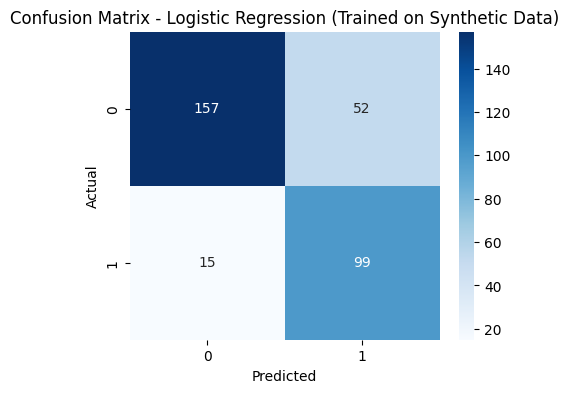

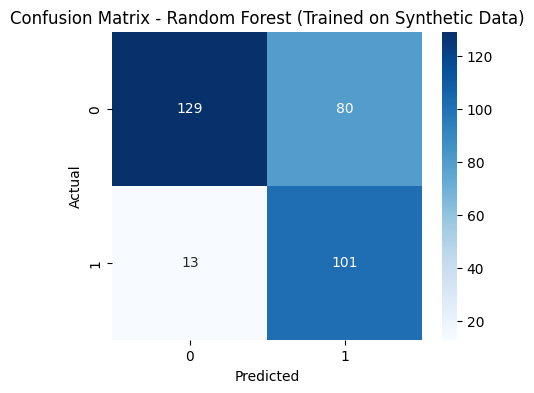

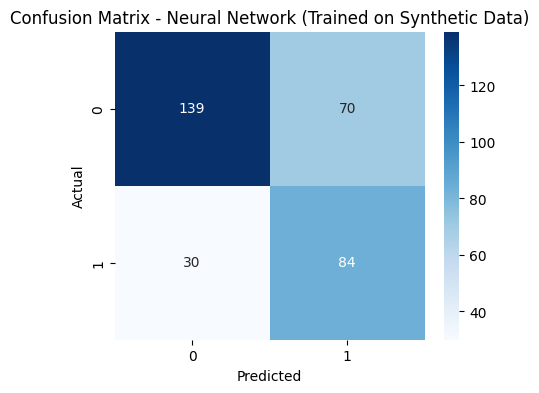

In [39]:
# Show confusion matrices for models trained on synthetic data
for name, cm in synthetic_confusion_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (Trained on Synthetic Data)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

<h1><center>Comparison of Real and Synthetic Data Performance</center></h1>

In this section, the performance of models trained on real data is compared with the performance of the same models trained on synthetic data generated by the CVAE. This comparison helps determine how effectively the synthetic dataset preserves the predictive information contained in the original clinical data.

The evaluation is based mainly on accuracy and F1-score, as these metrics provide a clear view of overall predictive quality and class-sensitive performance. The comparison is presented through a summary table and visualized using bar charts.

In [40]:
# Prepare real vs synthetic comparison table
comparison_df = pd.concat([real_results_df, synthetic_results_df], ignore_index=True)
comparison_df = comparison_df[["Model", "Train Data", "Accuracy", "Precision", "Recall", "F1 Score"]]
comparison_df = comparison_df.sort_values(by=["Model", "Train Data"]).reset_index(drop=True)

comparison_df.round(4)

,Model,Train Data,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Real,0.8266,0.8274,0.8266,0.8270
1,Logistic Regression,Synthetic,0.7926,0.8220,0.7926,0.7970
2,Neural Network,Real,0.7864,0.7868,0.7864,0.7866
3,Neural Network,Synthetic,0.6904,0.7247,0.6904,0.6971
4,Random Forest,Real,0.9474,0.9475,0.9474,0.9474
5,Random Forest,Synthetic,0.7121,0.7848,0.7121,0.7173


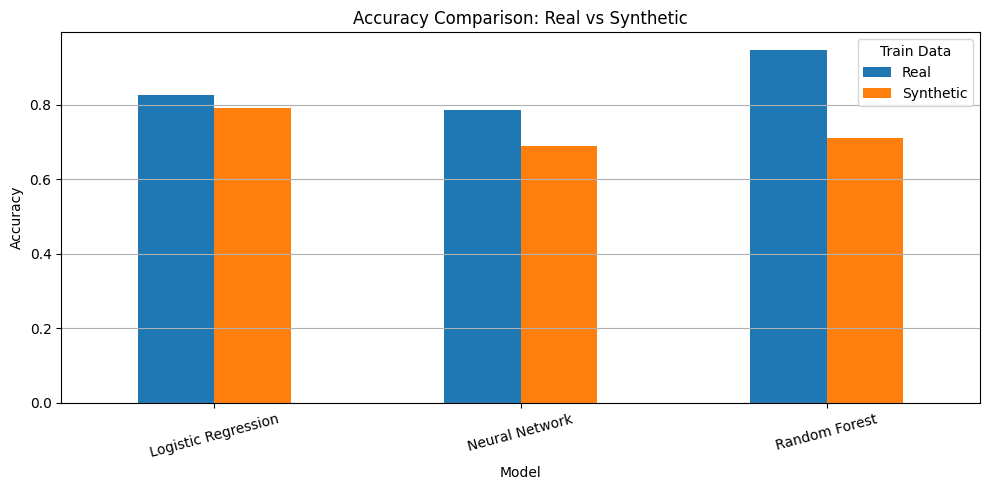

In [41]:
pivot_acc = comparison_df.pivot(index="Model", columns="Train Data", values="Accuracy")
pivot_acc.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Real vs Synthetic")
plt.xticks(rotation=15)
plt.legend(title="Train Data")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

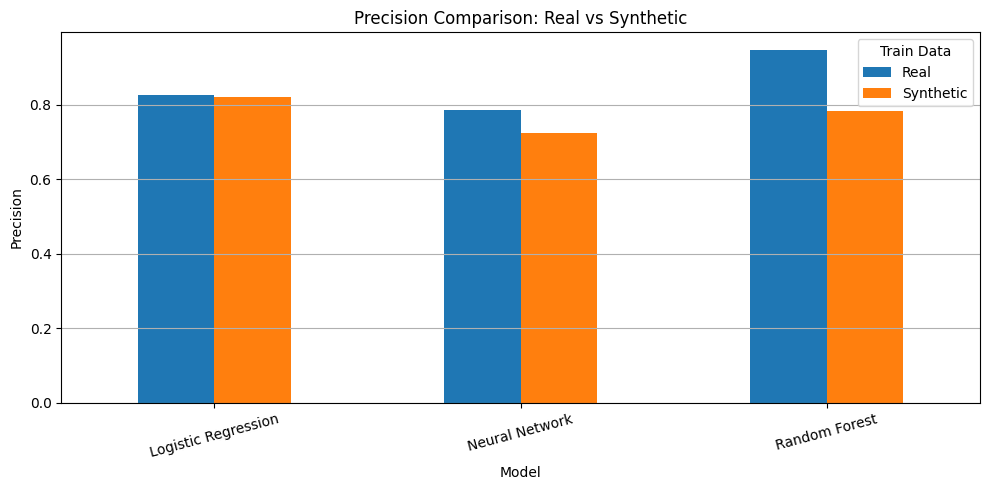

In [42]:
# Precision comparison: Real vs Synthetic
pivot_precision = comparison_df.pivot(index="Model", columns="Train Data", values="Precision")
pivot_precision.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Precision")
plt.title("Precision Comparison: Real vs Synthetic")
plt.xticks(rotation=15)
plt.legend(title="Train Data")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

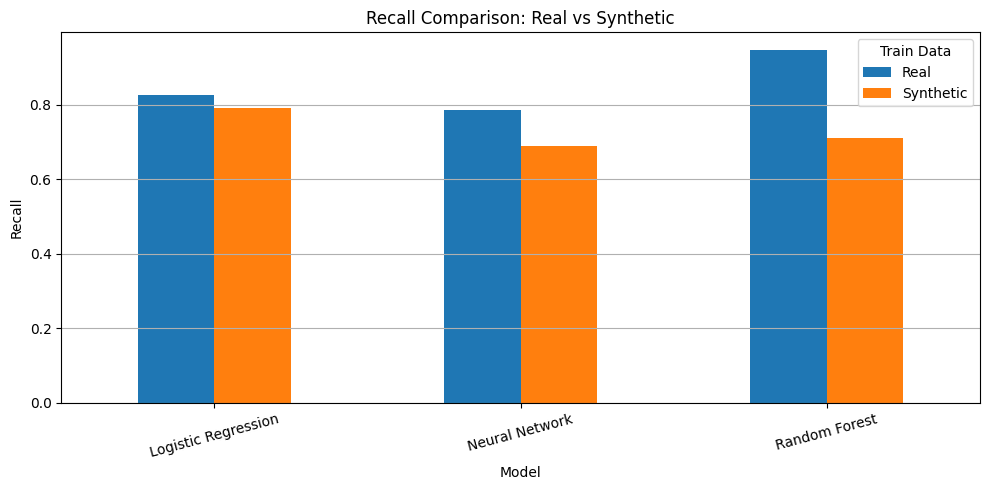

In [43]:
# Recall comparison: Real vs Synthetic
pivot_recall = comparison_df.pivot(index="Model", columns="Train Data", values="Recall")
pivot_recall.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Recall")
plt.title("Recall Comparison: Real vs Synthetic")
plt.xticks(rotation=15)
plt.legend(title="Train Data")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

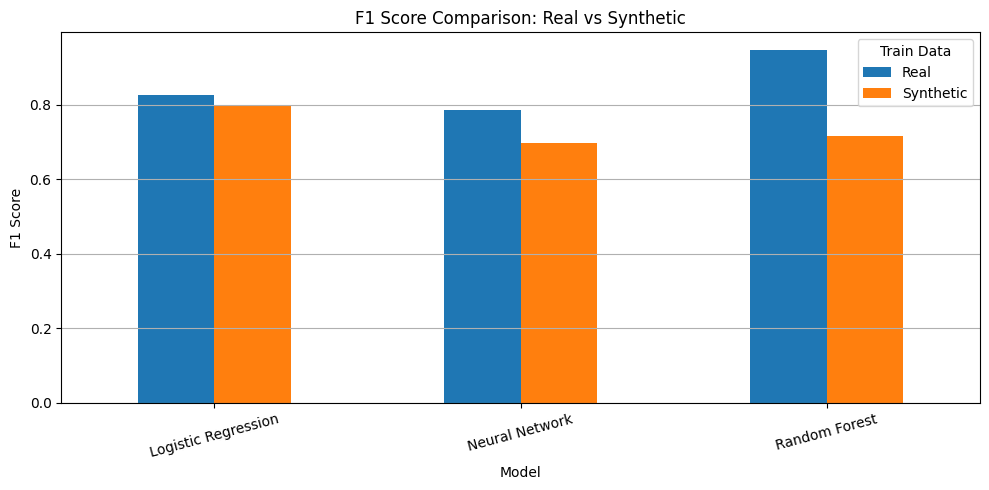

In [44]:
pivot_f1 = comparison_df.pivot(index="Model", columns="Train Data", values="F1 Score")
pivot_f1.plot(kind="bar", figsize=(10, 5))
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison: Real vs Synthetic")
plt.xticks(rotation=15)
plt.legend(title="Train Data")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Results Interpretation

The comparison between models trained on real data and models trained on synthetic data shows how well the generated dataset preserves useful predictive patterns. In general, models trained on real data are expected to achieve stronger performance, since they learn directly from the original feature distribution. However, if the models trained on synthetic data reach reasonably close Accuracy and F1 Score values, this suggests that the VAE-generated data captures important structural information from the original dataset.

These results indicate that synthetic healthcare data may be useful as a supportive resource in medical prediction tasks, especially in situations where real data is limited or sensitive. At the same time, any performance gap between real-data and synthetic-data training highlights the current limitations of synthetic data quality and the need for further improvement in generative modeling.

## Conclusion of the Experiment

Overall, the experiment shows that Variational Autoencoders can generate synthetic tabular healthcare data that is useful for model training, although models trained on real data still provide the most reliable performance. This supports the idea that synthetic data can be a promising complementary solution for healthcare machine learning, particularly for privacy-preserving research and low-data scenarios.